In [1]:
import random
import torch
import geospaNN
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

path = '../data/Output/'

R callback write-console: Loading required package: BRISC
  
R callback write-console: Loading required package: RANN
  
R callback write-console: Loading required package: parallel
  
R callback write-console: Loading required package: rdist
  
R callback write-console: Loading required package: matrixStats
  
R callback write-console: Loading required package: pbapply
  
R callback write-console: The ordering of inputs x (covariates) and y (response) in BRISC_estimation has been changed BRISC 1.0.0 onwards.
  Please check the new documentation with ?BRISC_estimation.
  


R package: BRISC installed


/Users/zhanwentao/miniforge3/envs/Test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def f1(X): return 10 * np.sin(2*np.pi * X)

p = 1;
funXY = f1

n = 1000
nn = 20

sigma = 1
phi = 0.3
Lambda = 0.01
theta = torch.tensor([sigma, phi / np.sqrt(2), Lambda])

X, Y, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, 1])

/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_17100/728254756.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2*np.pi * X)


In [3]:
torch.manual_seed(2025)
_, _, _, _, X = geospaNN.Simulation(n, p, nn, funXY, torch.tensor([1, 5, 0.01]), range=[0, 1])
X = X.reshape(-1,p)
X = (X - X.min(dim=0).values) / (X.max(dim=0).values - X.min(dim=0).values)
torch.manual_seed(2025)
_, _, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, 1])
Y = funXY(X).reshape(-1) + corerr

/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_17100/728254756.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2*np.pi * X)
/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_17100/728254756.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2*np.pi * X)


<Figure size 640x480 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

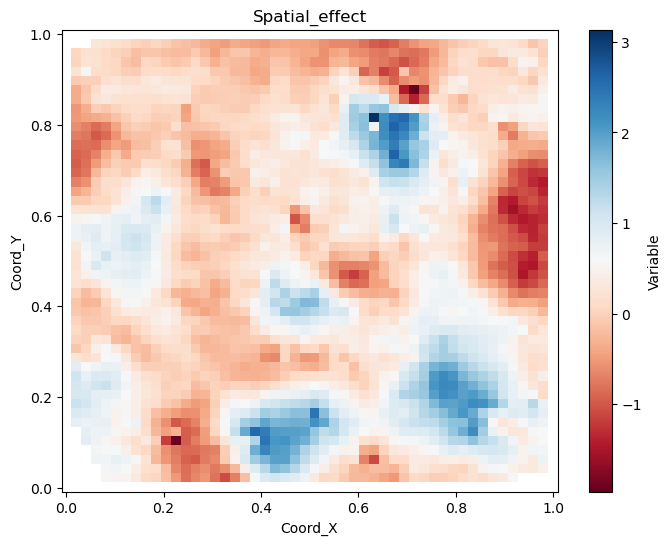

In [4]:
dict = {"Covariate": X, "Response": Y, "Spatial_effect":corerr}

for index, (name, variable) in enumerate(dict.items()):
    geospaNN.spatial_plot_surface(variable.detach().numpy().reshape(-1), coord.detach().numpy(),
                             grid_resolution = 50, method = "CloughTocher", cmap = "RdBu",
                             title = name, save_path = path, file_name = name + "_RdBu.png")

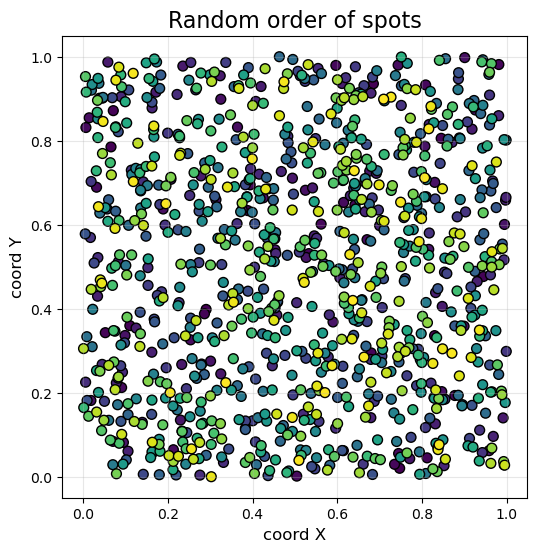

In [5]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(coord[:,0], coord[:,1], c = range(n), cmap='viridis', s=50, edgecolor='k')

# Customize the plot
plt.title('Random order of spots', fontsize=16)
plt.xlabel('coord X', fontsize=12)
plt.ylabel('coord Y', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig(path + "order_none.png")

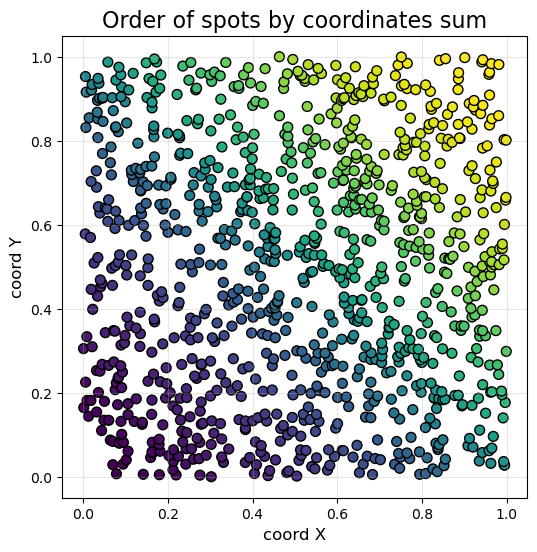

In [6]:
_, _, _, order = geospaNN.spatial_order(X, Y, coord, method='coord-sum')
plt.figure(figsize=(6, 6))
sc = plt.scatter(coord[order,0], coord[order,1], c = range(n), cmap='viridis', s=50, edgecolor='k')
# Customize the plot
plt.title('Order of spots by coordinates sum', fontsize=16)
plt.xlabel('coord X', fontsize=12)
plt.ylabel('coord Y', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig(path + "order_coord-sum.png")

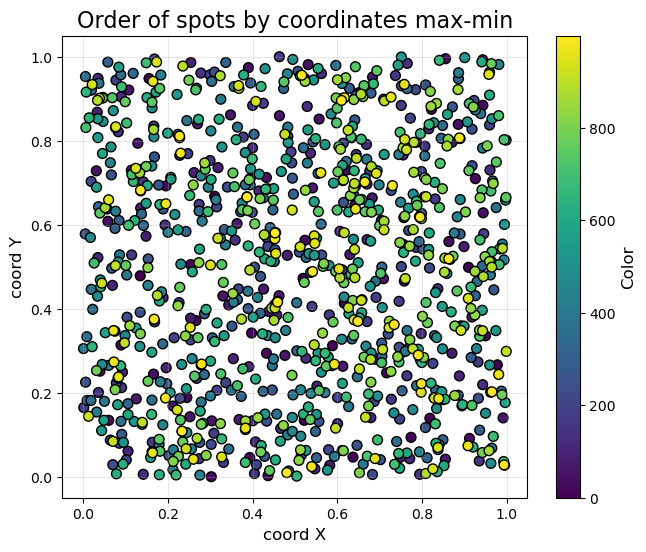

In [7]:
random.seed(2024)
_, _, _, order = geospaNN.spatial_order(X, Y, coord, method='max-min')
plt.figure(figsize=(7.5, 6))
sc = plt.scatter(coord[order,0], coord[order,1], c = range(n), cmap='viridis', s=50, edgecolor='k')
cbar = plt.colorbar(sc)
cbar.set_label('Color', fontsize=12)
# Customize the plot
plt.title('Order of spots by coordinates max-min', fontsize=16)
plt.xlabel('coord X', fontsize=12)
plt.ylabel('coord Y', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig(path + "order_max-min.png")

In [8]:
data = geospaNN.make_graph(X, Y, coord, nn, Ind_list = None)

np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn, 
                                                      test_proportion=0.2, val_proportion=0.2)

In [9]:
torch.manual_seed(2025)
_, _, coord_simp, _, corerr_simp = geospaNN.Simulation(n, p, nn, funXY, 
                                                       torch.tensor([1,1.5,0.01]), range=[0, 10])
theta_hat = geospaNN.theta_update(corerr_simp, coord_simp, neighbor_size=20)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 1000 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization


/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_17100/728254756.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2*np.pi * X)


----------------------------------------
	Processing optimizers
----------------------------------------


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (coords, y, x = NULL, sigma.sq = 1, tau.sq = 0.1, phi = 1,  :  
R callback write-console: 
   
R callback write-console:  The ordering of inputs x (covariates) and y (response) in BRISC_estimation has been changed BRISC 1.0.0 onwards.
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.88942915 1.74742544 0.01030127]


In [10]:
torch.manual_seed(2024)
mlp_nn = torch.nn.Sequential(
    torch.nn.Linear(p, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1),
)
trainer_nn = geospaNN.nn_train(mlp_nn, lr=0.01, min_delta=0.001)
training_log = trainer_nn.train(data_train, data_val, data_test, epoch_num= 200,
                                batch_size = 60, seed = 2025)
theta0 = geospaNN.theta_update(mlp_nn(data_train.x).squeeze() - data_train.y, 
                               data_train.pos, neighbor_size=20)

INFO: Early stopping
End at epoch82
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.17271566 6.89136661 0.11380343]


In [11]:
torch.manual_seed(2024)
mlp_nngls = torch.nn.Sequential(
    torch.nn.Linear(p, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1),
)
model = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nngls, 
                       theta=torch.tensor(theta0))
trainer_nngls = geospaNN.nngls_train(model, lr=0.01, min_delta=0.001)
training_log = trainer_nngls.train(data_train, data_val, data_test, epoch_num= 200, 
                                   Update_init=20, Update_step=5, 
                                   batch_size = 60, seed = 2025)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.3057617  8.04128348 0.24808237]
to
[0.3057617  8.04128348 0.24808237]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.23593388 7.2954745  0.11958859]
to
[0.23593388 7.2954745  0.11958859]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[ 0.25730161 10.52016322  0.06388105]
to
[ 0.25730161 10.52016322  0.06388105]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.34885507 1.70557464 0.0089827 ]
to
[0.34885507 1.70557464 0.0089827 ]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.4220595  1.41216384 0.00570824]
to
[0.4220595  1.41216384 0.00570824]
INFO: Early stopping
End at epoch57


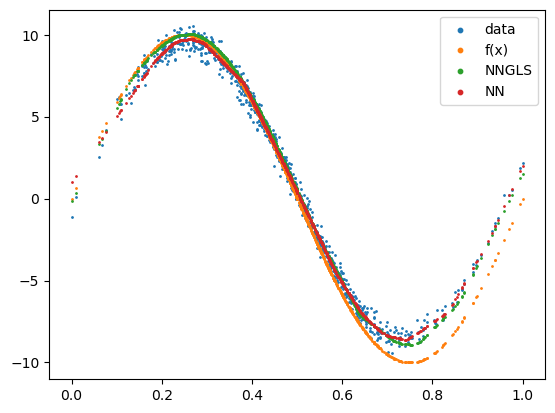

In [12]:
estimate = model.estimate(X)
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), estimate, s=1, label='NNGLS')
plt.scatter(X.detach().numpy(), mlp_nn(X).detach().numpy(), s=1, label='NN')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'Estimation.png')

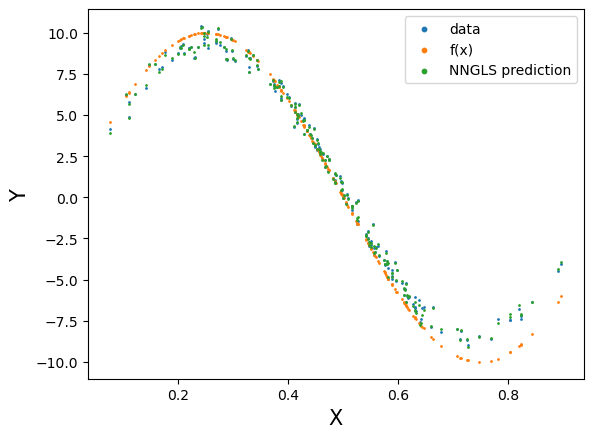

In [13]:
[test_predict, test_PI_U, test_PI_L] = model.predict(data_train, data_test, PI = True)
x_np = data_test.x.detach().numpy().reshape(-1)
x_smooth = np.linspace(x_np.min(), x_np.max(), 200)  # Create finer x-points
degree = 4
U_fit = np.polyfit(x_np, test_PI_U, degree)
L_fit = np.polyfit(x_np, test_PI_L, degree)
Pred_fit = np.polyfit(x_np, test_predict, degree)

# Evaluate the polynomial on a smooth grid
y_smooth_U = np.polyval(U_fit, x_smooth)
y_smooth_L = np.polyval(L_fit, x_smooth)
y_smooth = np.polyval(Pred_fit, x_smooth)

plt.clf()
plt.scatter(data_test.x.detach().numpy(), data_test.y.detach().numpy(), s=1, label='data')
plt.scatter(data_test.x.detach().numpy(), funXY(data_test.x.detach().numpy()), s=1, label='f(x)')
plt.scatter(data_test.x.detach().numpy(), test_predict.detach().numpy(), s=1, label='NNGLS prediction')
plt.xlabel("X", fontsize=15)
plt.ylabel("Y", fontsize=15)
lgnd = plt.legend()
for handle in lgnd.legend_handles[:3]:
    handle.set_sizes([10.0])
plt.savefig(path + "Prediction_no_PI.png")

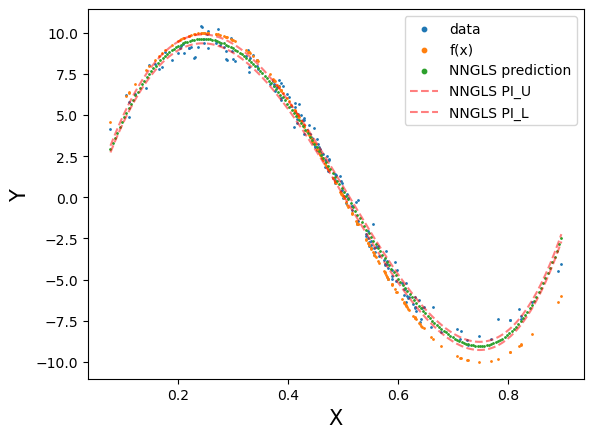

In [14]:
plt.clf()
plt.scatter(data_test.x.detach().numpy(), data_test.y.detach().numpy(), s=1, label='data')
plt.scatter(data_test.x.detach().numpy(), funXY(data_test.x.detach().numpy()), s=1, label='f(x)')
plt.scatter(x_smooth, y_smooth, s=1, label='NNGLS prediction')
plt.plot(x_smooth, y_smooth_U, linestyle='--', label='NNGLS PI_U', color = 'red', alpha = 0.5)
plt.plot(x_smooth, y_smooth_L, linestyle='--', label='NNGLS PI_L', color = 'red', alpha = 0.5)
plt.xlabel("X", fontsize=15)
plt.ylabel("Y", fontsize=15)
lgnd = plt.legend()
for handle in lgnd.legend_handles[:3]:
    handle.set_sizes([10.0])
plt.savefig(path + "Prediction_smoothed_PI.png")

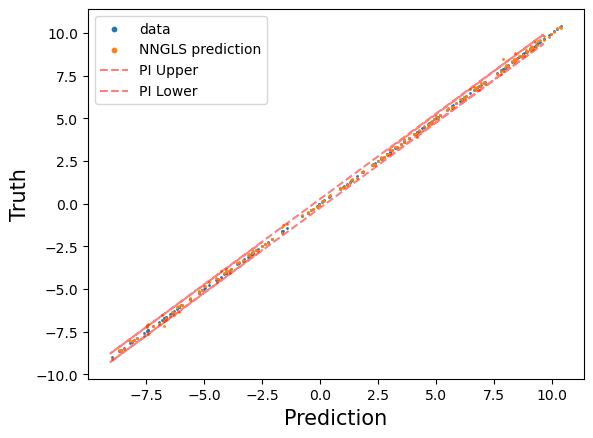

In [15]:
plt.clf()
plt.scatter(data_test.y.detach().numpy(), data_test.y.detach().numpy(), s=1, label='data')
plt.scatter(data_test.y.detach().numpy(), test_predict.detach().numpy(), s=1, label='NNGLS prediction')
plt.plot(y_smooth, y_smooth_U, linestyle='--', label='PI Upper', color = 'red', alpha = 0.5)
plt.plot(y_smooth, y_smooth_L, linestyle='--', label='PI Lower', color = 'red', alpha = 0.5)
plt.xlabel("Prediction", fontsize=15)
plt.ylabel("Truth", fontsize=15)
lgnd = plt.legend()
for handle in lgnd.legend_handles[:2]:
    handle.set_sizes([10.0])
plt.savefig(path + "Prediction_vs_no_PI.png")

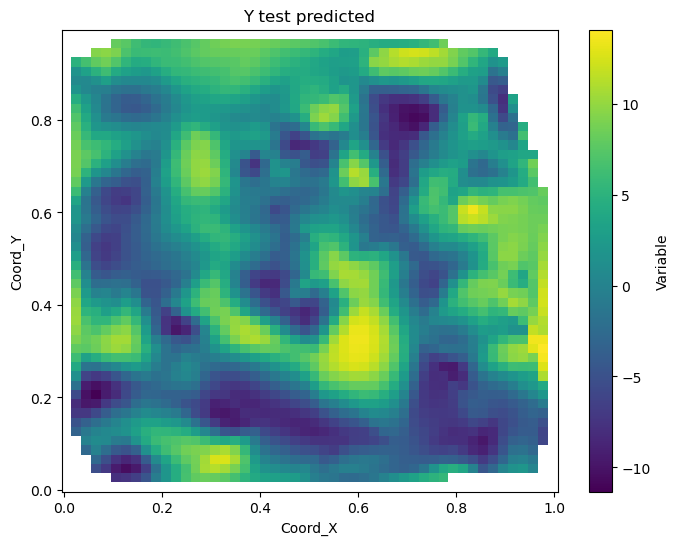

<Figure size 640x480 with 0 Axes>

<Figure size 800x600 with 0 Axes>

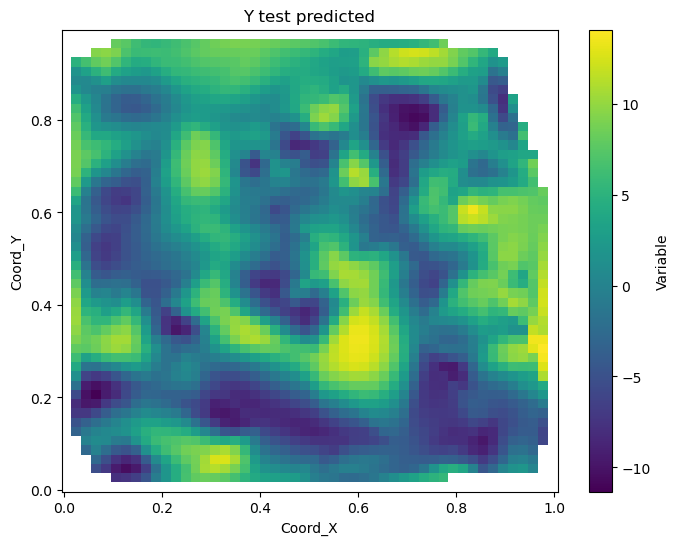

In [16]:
geospaNN.spatial_plot_surface(data_test.y.detach().numpy(), data_test.pos.detach().numpy(),
                              grid_resolution = 50, method = "CloughTocher",
                              title = "Y test", save_path = path, file_name = "Y_test" + ".png")
geospaNN.spatial_plot_surface(test_predict.detach().numpy(), data_test.pos.detach().numpy(),
                              grid_resolution = 50, method = "CloughTocher",
                              title = "Y test predicted", save_path = path, file_name = "Y_test_predicted" + ".png")

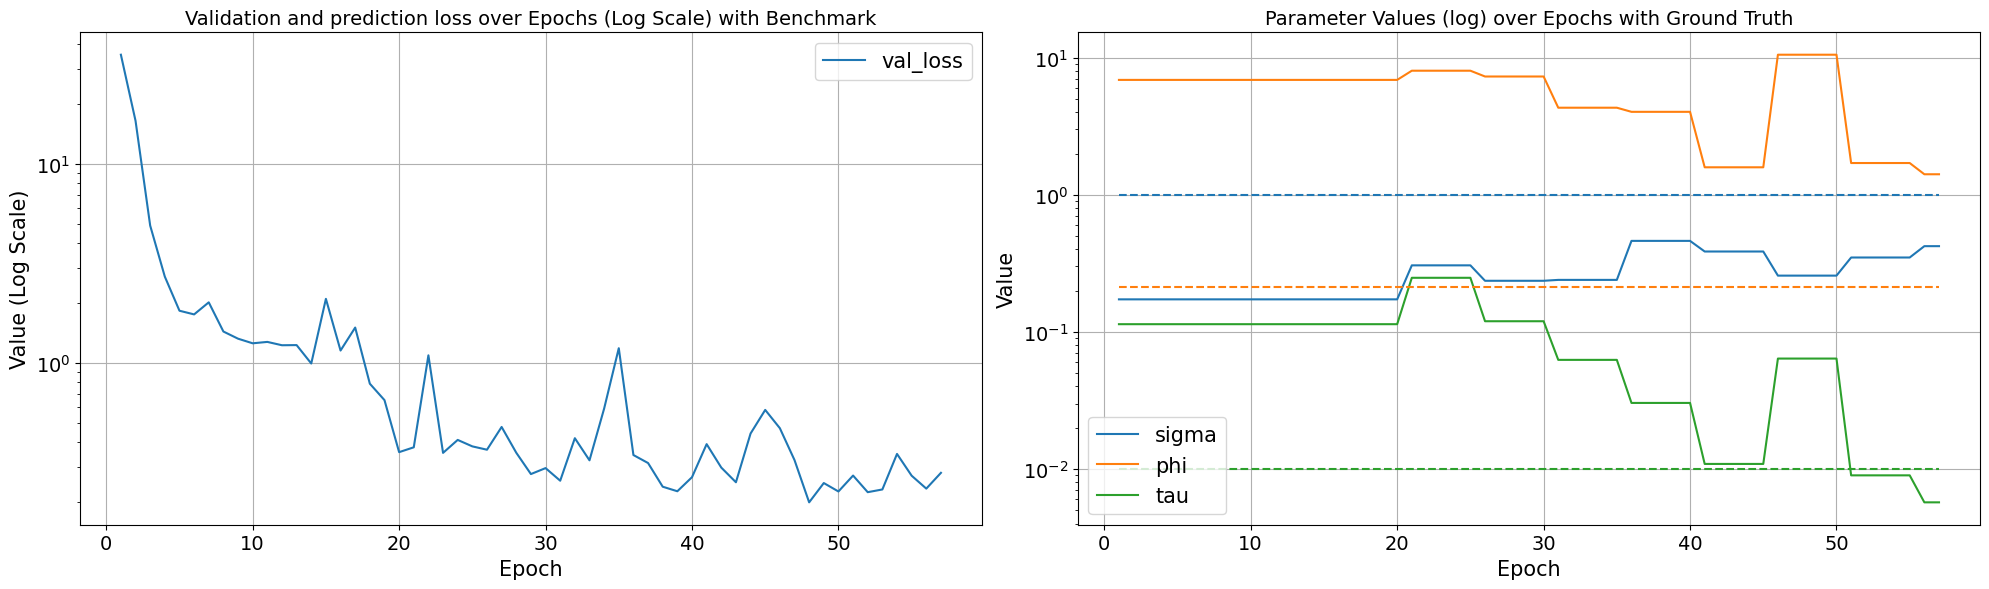

In [17]:
geospaNN.plot_log(training_log, theta, path, save = True)